# Lab 3

0. Egg-Yoke transformation to linear separability

In [109]:
import pandas as pd
import numpy as np

data_train = pd.read_csv("eggyoke_traindata.csv")

X_train = data_train[["x_1", "x_2"]].to_numpy()
y_train = data_train["y"].to_numpy()


data_test = pd.read_csv("eggyoke_testdata.csv")

X_test = data_test[["x_1", "x_2"]].to_numpy()
y_test = data_test["y"].to_numpy()

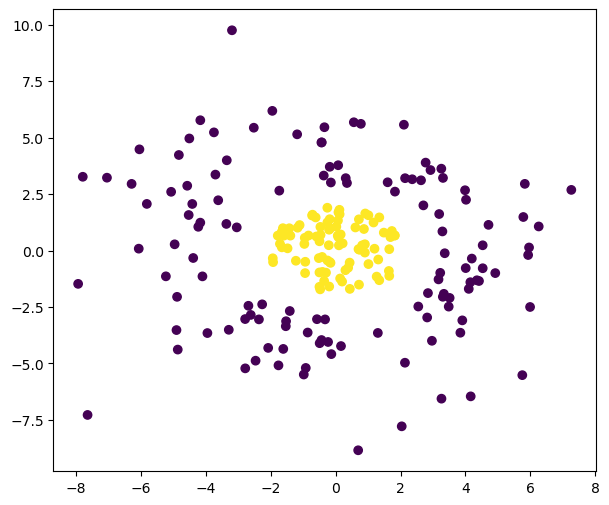

In [110]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))
plt.scatter(X_train[:,0], X_train[:,1], c=y_train)
plt.show()

\begin{equation*}
\text{r} = \sqrt{x_1^2 + x_2^2} \
\end{equation*}

\begin{equation*}
\theta = \arctan{\frac{x_2}{x_1}}
\end{equation*}

In [111]:
def phi(x1, x2):

    return np.sqrt(x1**2 + x2**2), np.arctan(x2/x1)

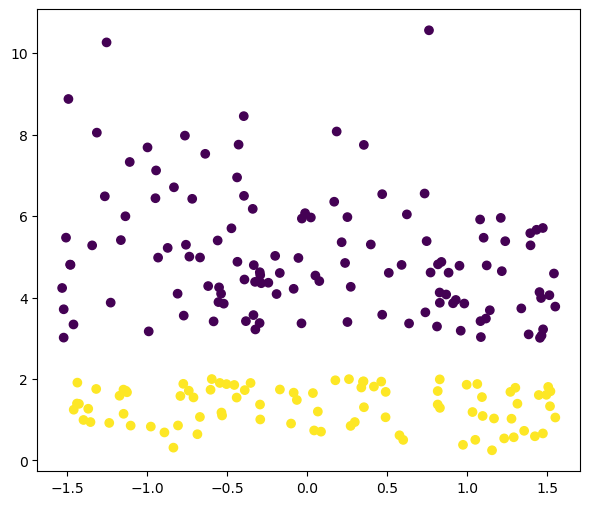

In [112]:
r, theta = phi(X_train[:,0], X_train[:,1])

plt.figure(figsize=(7,6))
plt.scatter(theta, r, c=y_train)
plt.show()

1. Apply SVC with linear kernel and then rbf or poly kernel to the 2 datasets. Compare the results

In [113]:
# Modify X_train and X_test with polar coordinates 
r_train, theta_train = phi(X_train[:,0], X_train[:,1])

r_test, theta_test = phi(X_test[:,0], X_test[:,1])

X_train_polar = np.column_stack((r_train, theta_train))
X_test_polar = np.column_stack((r_test, theta_test))

In [114]:
import sklearn as sl
from sklearn.metrics import accuracy_score

#SVC using a linear kernel
model_linear = sl.svm.SVC(kernel='linear')
model_linear.fit(X_train_polar, y_train)

y_pred = model_linear.predict(X_train_polar)
training_AC = accuracy_score(y_train, y_pred)

y_pred_test = model_linear.predict(X_test_polar)
generalization_AC = accuracy_score(y_test, y_pred_test)

print(f"The training accuracy score is {training_AC}")
print(f"The generalization accuracy score is {generalization_AC}")

The training accuracy score is 1.0
The generalization accuracy score is 1.0


In [283]:
#SVC using a rbf kernel
model_rbf = sl.svm.SVC(kernel='rbf')
model_rbf.fit(X_train, y_train)

y_pred = model_rbf.predict(X_train)
training_AC = accuracy_score(y_train, y_pred)

y_pred_test = model_rbf.predict(X_test)
generalization_AC = accuracy_score(y_test, y_pred_test)

print(f"The training accuracy score is {training_AC}")
print(f"The generalization accuracy score is {generalization_AC}")

The training accuracy score is 1.0
The generalization accuracy score is 1.0


As we've seen, all points are well predicted for both poly and linear kernel. This can be explained by the fact that our data set is linearly separable.

2. Identify the attributes of SVC class that will allow you to reconstruct the decision function
\begin{equation*}
y(x) = \sum_{i=1}^{m}a_it_ik(\underline{x},\underline{x}_i ) + w_0
\end{equation*}

For the linear kernel, the useful attirbutes of SVC are dual_coef_ which give us the $a_it_i$, the support_vectors_ attribute and the intercept which is the bias $w_0$

For the rbf kernel, the useful attirbutes of SVC are dual_coef_ which give us the $a_it_i$, the support_vectors_ attribute, the intercept which is the bias $w_0$ and the gamma attribute $\gamma$ which is a hyperparameter

3. Plot the decision function you reconstructed.


The decision function is defined like:
\begin{equation*}
w_1r + w_2\theta + w_0 = 0
\end{equation*}
Then we obtain: 

\begin{equation*}
r = -\frac{w_2}{w_1}\theta -\frac{w_0}{w_1}
\end{equation*}

In [284]:
dual_coef_linear = model_linear.dual_coef_
sv = model_linear.support_vectors_
w_0 = model_linear.intercept_[0]

w = np.sum(dual_coef_linear @ sv, axis=0)

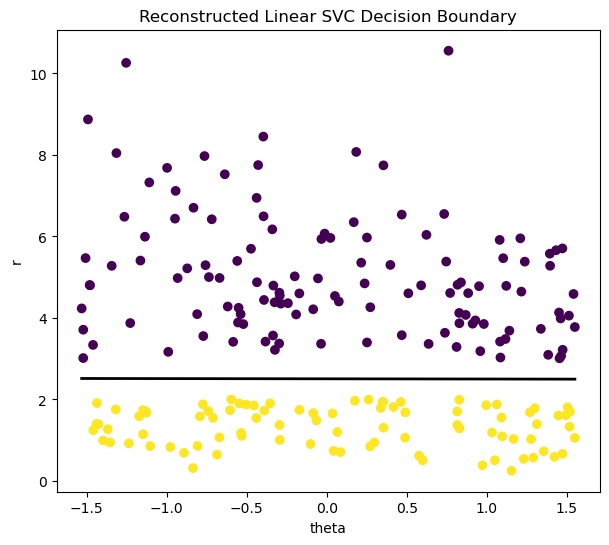

In [285]:
theta_line = np.linspace(theta_train.min(), theta_train.max())

r_line = -(w[1] / w[0]) * theta_line - w_0 / w[0]

plt.figure(figsize=(7,6))
plt.scatter(theta_train, r_train, c=y_train)
plt.plot(theta_line, r_line, color="black", linewidth=2)
plt.xlabel("theta")
plt.ylabel("r")
plt.title("Reconstructed Linear SVC Decision Boundary")
plt.show()


With rbf kernel we get:

\begin{equation*}
y(\mathbf{x}) = \sum_{i=1}^{m}a_it_i(\exp(-\gamma||\underline{x} - \underline{x}_i||^2)  + w_0
\end{equation*}


In [286]:
dual_coef_rbf = model_rbf.dual_coef_[0]
sv = model_rbf.support_vectors_
w_0 = model_rbf.intercept_[0]
gamma = model_rbf._gamma

In [303]:

#create a grid of points with shape (210,2)
x_1 = np.linspace(X_train[:,0].min(), X_train[:,0].max(), len(X_train))
x_2 = np.linspace(X_train[:,1].min(), X_train[:,1].max(), len(X_train[0]))

X_1,X_2 = np.meshgrid(x_1,x_2)

grid = np.c_[X_1.ravel(), X_2.ravel()]

In [317]:
# Recompute the decision boundary
y = np.zeros(grid.shape[0]) 

for i in range(len(sv)):
    dist2 = np.linalg.norm(grid - sv[i], axis=1)**2
    y += dual_coef_rbf[i] * np.exp(-gamma * dist2)

#y += w_0
y = y.reshape(X_1.shape)

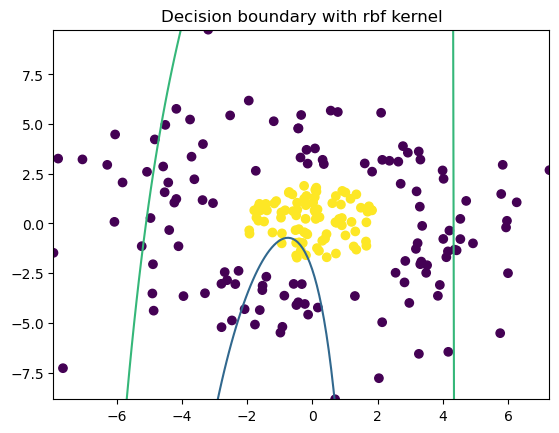

In [321]:
fig, ax = plt.subplots()
plt.scatter(X_train[:,0], X_train[:,1], c=y_train)
ax.contour(X_1, X_2, y, 1)
ax.set_title('Decision boundary with rbf kernel')
plt.show()

I know that the rbf function should encircle the yellow points. Hence,  my rbf function is wrong 